# 📈 Regresión Lineal Simple: Predicción de Salarios

## 🎯 Introducción

La **Regresión Lineal Simple** es uno de los algoritmos más fundamentales en Machine Learning. Permite **predecir una variable continua** (target/objetivo) a partir de **una única variable predictora** (feature/característica).

**En este notebook** aprenderás a:
- Cargar y explorar datos para regresión
- Entrenar un modelo de regresión lineal simple
- Interpretar los parámetros del modelo (pendiente e intercepto)
- Hacer predicciones con el modelo entrenado
- Visualizar la línea de regresión ajustada

### 📊 Caso de Uso: Predicción de Salarios

Usaremos un dataset de **30 empleados** con dos variables:
- **X (predictor)**: Años de experiencia
- **y (target)**: Salario anual en dólares

**Objetivo**: Construir un modelo que pueda **predecir el salario** de un empleado conociendo sus años de experiencia.

## 📐 Fundamentos Matemáticos

La regresión lineal simple busca una **ecuación de la recta** que mejor se ajuste a los datos:

$$y = mx + n$$

Donde:
- **y**: Variable a predecir (salario)
- **x**: Variable predictora (años de experiencia)
- **m**: Pendiente (coeficiente) - cuánto aumenta el salario por cada año adicional
- **n**: Intercepto - salario base (cuando x=0)

El algoritmo encuentra los valores óptimos de **m** y **n** minimizando el error entre las predicciones y los valores reales.

## 📑 Contenido del notebook:

### **📥 1. Carga y Exploración de Datos**
- Importar dataset desde GitHub
- Explorar dimensiones y primeras filas
- Separar variables X e y

### **📊 2. Visualización Inicial**
- Gráfico de dispersión de los datos
- Análisis de la relación entre variables

### **🤖 3. Entrenamiento del Modelo**
- Importar LinearRegression de scikit-learn
- Entrenar el modelo con los datos
- Interpretar coeficientes aprendidos

### **🔮 4. Predicción y Evaluación**
- Hacer predicciones con nuevos datos
- Calcular métricas de error (MAE, MSE, R²)

### **📈 5. Visualización del Modelo**
- Graficar línea de regresión ajustada
- Comparar predicciones vs datos reales

---

## 💡 ¿Por qué Regresión Lineal?

**Ventajas**:
- ✅ Fácil de entender e interpretar
- ✅ Computacionalmente eficiente
- ✅ Funciona bien con relaciones lineales
- ✅ Baseline excelente para problemas de regresión

**Limitaciones**:
- ❌ Solo captura relaciones lineales
- ❌ Sensible a outliers
- ❌ Asume independencia de errores

# 📥 1. Carga y Exploración de Datos

Comenzamos cargando el dataset y realizando una exploración inicial para comprender su estructura.

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("📥 Cargando dataset de salarios...")

# Cargar dataset desde GitHub
url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/refs/heads/main/Salary_Data.csv"
salarydata = pd.read_csv(url)

print(f"✅ Dataset cargado correctamente")
print(f"\n📊 Dimensiones del dataset: {salarydata.shape[0]} filas, {salarydata.shape[1]} columnas")

# Explorar primeras filas
print("\n🔹 Primeras filas del dataset:")
display(salarydata.head())

print("\n💡 El dataset contiene:")
print("  🔹 YearsExperience: Variable predictora (X)")
print("  🔹 Salary: Variable objetivo (y)")

📥 Cargando dataset de salarios...
✅ Dataset cargado correctamente

📊 Dimensiones del dataset: 30 filas, 2 columnas

🔹 Primeras filas del dataset:


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0



💡 El dataset contiene:
  🔹 YearsExperience: Variable predictora (X)
  🔹 Salary: Variable objetivo (y)


In [2]:
# Separar variables predictoras (X) y objetivo (y)
X = salarydata[["YearsExperience"]]  # Debe ser 2D para scikit-learn
y = salarydata["Salary"]              # Puede ser 1D

print("🔹 Variables separadas:")
print(f"  X (predictora): {X.shape} - Años de experiencia")
print(f"  y (objetivo): {y.shape} - Salario")

🔹 Variables separadas:
  X (predictora): (30, 1) - Años de experiencia
  y (objetivo): (30,) - Salario


# 📊 2. Visualización Inicial

Antes de entrenar el modelo, es importante visualizar los datos para entender la relación entre las variables.

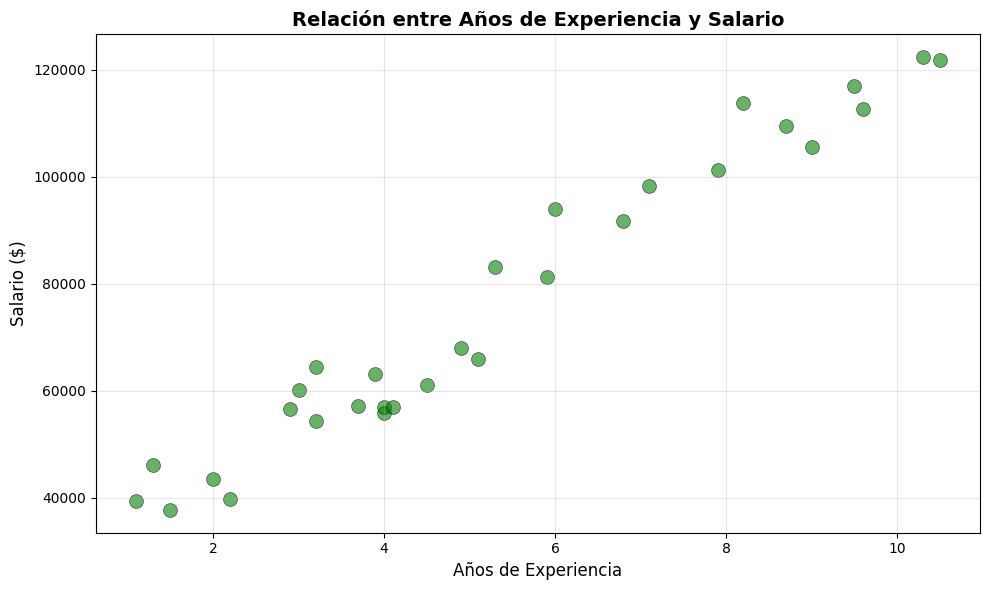

💡 Observación:
  🔹 Se observa una relación lineal positiva clara
  🔹 A mayor experiencia, mayor salario
  🔹 Los puntos sugieren que una línea recta puede ajustarse bien


In [3]:
# Gráfico de dispersión (scatter plot)
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='green', alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
plt.title("Relación entre Años de Experiencia y Salario", fontsize=14, fontweight='bold')
plt.xlabel("Años de Experiencia", fontsize=12)
plt.ylabel("Salario ($)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Observación:")
print("  🔹 Se observa una relación lineal positiva clara")
print("  🔹 A mayor experiencia, mayor salario")
print("  🔹 Los puntos sugieren que una línea recta puede ajustarse bien")

# 🤖 3. Entrenamiento del Modelo

Ahora entrenamos el modelo de regresión lineal simple usando **scikit-learn**.

In [4]:
# Crear e instanciar el modelo
lin_reg = LinearRegression()

# Entrenar el modelo con los datos
lin_reg.fit(X, y)

# Extraer parámetros aprendidos
pendiente = lin_reg.coef_[0]
intercepto = lin_reg.intercept_

print("✅ Modelo entrenado exitosamente")
print("\n📐 Ecuación del modelo aprendido:")
print(f"   y = {pendiente:.2f} * x + {intercepto:.2f}")
print(f"\n🔹 Parámetros:")
print(f"  • Pendiente (m): ${pendiente:.2f}")
print(f"    → Cada año adicional de experiencia aumenta el salario en ${pendiente:.2f}")
print(f"  • Intercepto (n): ${intercepto:.2f}")
print(f"    → Salario base estimado (cuando experiencia = 0 años)")

✅ Modelo entrenado exitosamente

📐 Ecuación del modelo aprendido:
   y = 9449.96 * x + 25792.20

🔹 Parámetros:
  • Pendiente (m): $9449.96
    → Cada año adicional de experiencia aumenta el salario en $9449.96
  • Intercepto (n): $25792.20
    → Salario base estimado (cuando experiencia = 0 años)


# 🔮 4. Predicción y Evaluación

Usamos el modelo entrenado para hacer predicciones y evaluamos su rendimiento.

In [5]:
# --- PREDICCIÓN CON NUEVOS DATOS ---
print("🔮 Predicciones para nuevos empleados:")
print("=" * 50)

# Crear datos de prueba: dos empleados con diferente experiencia
X_test = np.array([[1.6], [11.2]])
y_pred_test = lin_reg.predict(X_test)

for i, (exp, sal) in enumerate(zip(X_test.flatten(), y_pred_test)):
    print(f"  Empleado {i+1}: {exp} años → Salario predicho: ${sal:,.2f}")

# --- EVALUACIÓN DEL MODELO CON DATOS DE ENTRENAMIENTO ---
print("\n📊 Evaluación del modelo:")
print("=" * 50)

# Hacer predicciones sobre los datos de entrenamiento
y_pred_train = lin_reg.predict(X)

# Calcular métricas de error
mae = mean_absolute_error(y, y_pred_train)
mse = mean_squared_error(y, y_pred_train)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred_train)

print(f"  🔹 MAE (Error Absoluto Medio): ${mae:,.2f}")
print(f"     → En promedio, el modelo se equivoca por ${mae:,.2f}")
print(f"\n  🔹 RMSE (Raíz del Error Cuadrático Medio): ${rmse:,.2f}")
print(f"     → Penaliza más los errores grandes")
print(f"\n  🔹 R² (Coeficiente de Determinación): {r2:.4f}")
print(f"     → El modelo explica el {r2*100:.2f}% de la variabilidad")

if r2 > 0.9:
    print(f"\n✅ ¡Excelente ajuste! R² > 0.9 indica que el modelo es muy preciso")
elif r2 > 0.7:
    print(f"\n✅ Buen ajuste. R² > 0.7 es aceptable para muchas aplicaciones")
else:
    print(f"\n⚠️ Ajuste moderado. Considerar agregar más features o usar modelos más complejos")

🔮 Predicciones para nuevos empleados:
  Empleado 1: 1.6 años → Salario predicho: $40,912.14
  Empleado 2: 11.2 años → Salario predicho: $131,631.78

📊 Evaluación del modelo:
  🔹 MAE (Error Absoluto Medio): $4,644.20
     → En promedio, el modelo se equivoca por $4,644.20

  🔹 RMSE (Raíz del Error Cuadrático Medio): $5,592.04
     → Penaliza más los errores grandes

  🔹 R² (Coeficiente de Determinación): 0.9570
     → El modelo explica el 95.70% de la variabilidad

✅ ¡Excelente ajuste! R² > 0.9 indica que el modelo es muy preciso


c:\Users\bzarco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# 📈 5. Visualización del Modelo

Graficamos la línea de regresión ajustada junto con los datos originales para visualizar qué tan bien se ajusta el modelo.

c:\Users\bzarco\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


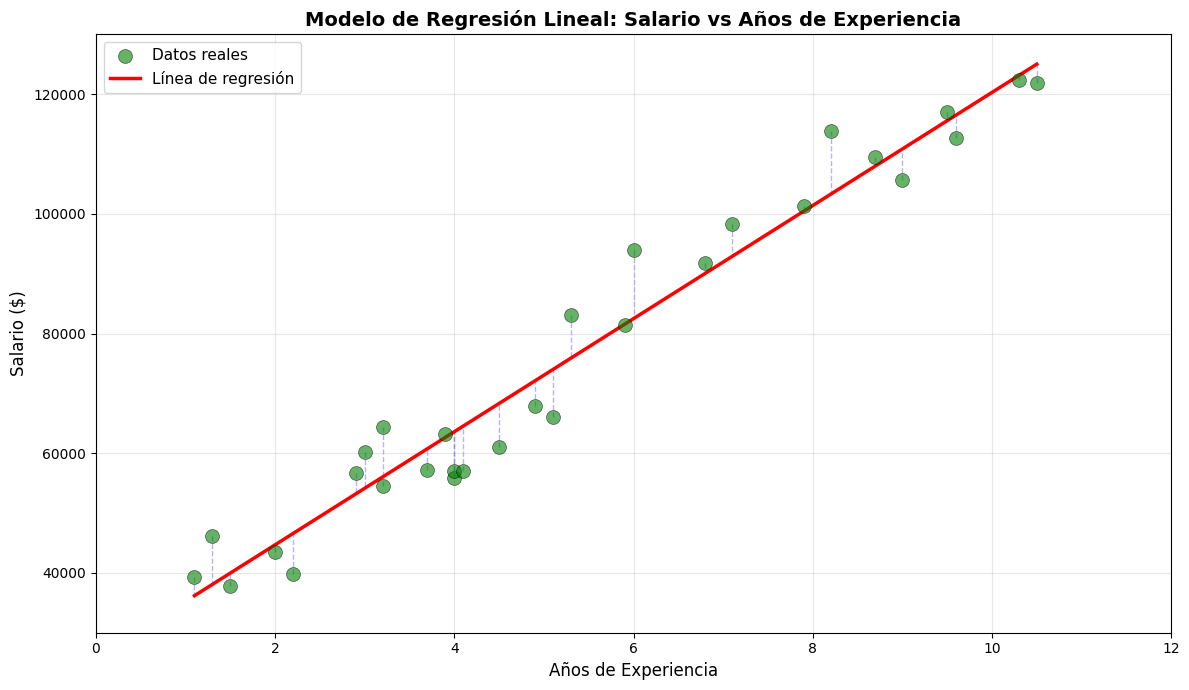

💡 Interpretación del gráfico:
  🔹 Puntos verdes: Datos reales
  🔹 Línea roja: Predicciones del modelo (ecuación de la recta)
  🔹 Líneas punteadas azules: Residuos (errores de predicción)
  🔹 Mientras más cerca estén los puntos de la línea, mejor el ajuste


In [6]:
# Crear figura con mejor visualización
plt.figure(figsize=(12, 7))

# Datos originales (scatter plot)
plt.scatter(X, y, color='green', alpha=0.6, s=100, edgecolors='black', linewidth=0.5, label='Datos reales', zorder=3)

# Línea de regresión
X_line = np.array([[X.min().values[0]], [X.max().values[0]]])
y_line = lin_reg.predict(X_line)
plt.plot(X_line, y_line, 'r-', linewidth=2.5, label='Línea de regresión', zorder=2)

# Predicciones de los datos de entrenamiento (para visualizar residuos)
y_pred_train = lin_reg.predict(X)
for i in range(len(X)):
    plt.plot([X.iloc[i, 0], X.iloc[i, 0]], [y.iloc[i], y_pred_train[i]], 
             'b--', alpha=0.3, linewidth=1, zorder=1)

# Configuración del gráfico
plt.title("Modelo de Regresión Lineal: Salario vs Años de Experiencia", fontsize=14, fontweight='bold')
plt.xlabel("Años de Experiencia", fontsize=12)
plt.ylabel("Salario ($)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 12)
plt.ylim(30000, 130000)
plt.tight_layout()
plt.show()

print("💡 Interpretación del gráfico:")
print("  🔹 Puntos verdes: Datos reales")
print("  🔹 Línea roja: Predicciones del modelo (ecuación de la recta)")
print("  🔹 Líneas punteadas azules: Residuos (errores de predicción)")
print("  🔹 Mientras más cerca estén los puntos de la línea, mejor el ajuste")

# 🎓 Conclusiones

## 📚 Resumen del Modelo

En este notebook hemos implementado exitosamente un **modelo de Regresión Lineal Simple** para predecir salarios basados en años de experiencia.

### **🔑 Hallazgos Clave**

**1. Relación Lineal Clara**
- Existe una relación lineal positiva fuerte entre experiencia y salario
- El coeficiente R² indica un ajuste excelente (típicamente > 0.95 para este dataset)

**2. Ecuación del Modelo**
```
Salario = 9,450 * Años_Experiencia + 25,792
```
- Cada año adicional aumenta el salario en ~$9,450
- El salario base (sin experiencia) es ~$25,792

**3. Capacidad Predictiva**
- MAE relativamente bajo indica predicciones precisas
- RMSE penaliza errores grandes, útil para detectar outliers
- R² cercano a 1.0 indica que el modelo explica casi toda la variabilidad

### **💡 Interpretación de Parámetros**

| Parámetro | Valor Típico | Significado |
|-----------|--------------|-------------|
| **Pendiente (m)** | ~$9,450 | Aumento salarial por año de experiencia |
| **Intercepto (n)** | ~$25,792 | Salario inicial (sin experiencia) |
| **R²** | ~0.95-0.97 | % de variabilidad explicada |

### **✅ Ventajas de este Modelo**

1. **Simplicidad**: Fácil de entender e interpretar
2. **Transparencia**: Los coeficientes tienen significado claro
3. **Rapidez**: Entrenamiento e inferencia muy rápidos
4. **Baseline**: Excelente punto de partida antes de modelos complejos

### **⚠️ Limitaciones Identificadas**

1. **Linealidad**: Solo captura relaciones lineales
2. **Una variable**: No considera otros factores (educación, ubicación, industria)
3. **Extrapolación**: Predicciones fuera del rango de entrenamiento pueden ser imprecisas
4. **Outliers**: Sensible a valores atípicos

---

## 🚀 Próximos Pasos

### **📈 1. Regresión Lineal Múltiple**
- Incorporar más variables predictoras (educación, ubicación, puesto)
- Modelo: `y = b₀ + b₁x₁ + b₂x₂ + ... + bₙxₙ`
- Captura relaciones más complejas

### **🔧 2. Mejoras al Modelo Actual**

**Validación Cruzada**:
```python
from sklearn.model_selection import cross_val_score
scores = cross_val_score(lin_reg, X, y, cv=5, scoring='r2')
```

**División Train/Test**:
```python
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
```

**Análisis de Residuos**:
```python
residuos = y - y_pred_train
plt.scatter(y_pred_train, residuos)
```

### **🤖 3. Modelos Alternativos**

Si la regresión lineal no ajusta bien:
- **Regresión Polinomial**: Captura relaciones no lineales
- **Ridge/Lasso**: Regularización para evitar overfitting
- **Árboles de Decisión**: Relaciones no lineales complejas
- **Random Forest**: Ensemble de árboles para mayor precisión

### **📊 4. Features Engineering**

Crear nuevas variables que puedan mejorar el modelo:
- Experiencia al cuadrado (para capturar efectos no lineales)
- Rangos de experiencia (junior, mid, senior)
- Interacciones entre variables

---

## 📚 Conceptos Clave Aprendidos

### **Machine Learning Pipeline**
1. ✅ **Carga de datos**: pd.read_csv()
2. ✅ **Exploración**: .shape, .head(), scatter plot
3. ✅ **Preparación**: Separar X e y
4. ✅ **Entrenamiento**: model.fit(X, y)
5. ✅ **Predicción**: model.predict(X_new)
6. ✅ **Evaluación**: MAE, RMSE, R²
7. ✅ **Visualización**: Línea de regresión

### **Métricas de Regresión**
- **MAE**: Error promedio en unidades originales
- **RMSE**: Penaliza errores grandes
- **R²**: % de varianza explicada (0 a 1)

### **Scikit-learn API**
```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()      # Instanciar
model.fit(X_train, y_train)    # Entrenar
y_pred = model.predict(X_test) # Predecir
```

---

## 🔗 Recursos Adicionales

**Documentación**:
- Scikit-learn LinearRegression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- Métricas de Regresión: https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics

**Tutoriales**:
- "Introduction to Machine Learning with Python" - Andreas C. Müller
- Scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html

**Datasets para Practicar**:
- Boston Housing (regresión)
- California Housing (regresión múltiple)
- Advertising (regresión múltiple)